<a href="https://colab.research.google.com/github/MsNatalie21/sprint4-final-project/blob/main/sprint4-final-project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sprint 4 Project: E-Commerce Customer Behavior EDA

Welcome to your Sprint 4 final project. In this project, you will apply everything you've learned across Sprints 1–4 to perform a complete Exploratory Data Analysis on the **Olist Brazilian E-Commerce dataset** — real data from a real e-commerce platform.


## Dataset

You'll work with 7 CSV files from the Olist e-commerce dataset:

| File | Rows | Description |
|---|---|---|
| `olist_orders_dataset.csv` | 99,441 | Orders with timestamps and status |
| `olist_order_items_dataset.csv` | 112,650 | Items per order with price and freight |
| `olist_customers_dataset.csv` | 99,441 | Customer ID, city, state |
| `olist_products_dataset.csv` | 32,951 | Products with category and dimensions |
| `olist_order_reviews_dataset.csv` | 99,224 | Review scores (1–5 stars) |
| `olist_order_payments_dataset.csv` | 103,886 | Payment type and value |
| `product_category_name_translation.csv` | 71 | Portuguese → English category names |

Let's get started!

---

## Setup

Run the cells below to import the libraries you'll need and load the datasets. The data is hosted on GitHub, so you can load it with one line of code per file — no uploads required.

In [1]:
# Import libraries
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

# Confirm versions
print(f"pandas version: {pd.__version__}")
print("Setup complete!")

pandas version: 2.2.2
Setup complete!


In [2]:
# Load the 7 datasets from the curriculum GitHub repo
BASE_URL = 'https://practicum-content.s3.us-west-1.amazonaws.com/data-analytics/eda-project/'

orders = pd.read_csv(BASE_URL + 'olist_orders_dataset.csv')
items = pd.read_csv(BASE_URL + 'olist_order_items_dataset.csv')
customers = pd.read_csv(BASE_URL + 'olist_customers_dataset.csv')
products = pd.read_csv(BASE_URL + 'olist_products_dataset.csv')
reviews = pd.read_csv(BASE_URL + 'olist_order_reviews_dataset.csv')
payments = pd.read_csv(BASE_URL + 'olist_order_payments_dataset.csv')
translation = pd.read_csv(BASE_URL + 'product_category_name_translation.csv')

print(f"orders:      {orders.shape}")
print(f"items:       {items.shape}")
print(f"customers:   {customers.shape}")
print(f"products:    {products.shape}")
print(f"reviews:     {reviews.shape}")
print(f"payments:    {payments.shape}")
print(f"translation: {translation.shape}")

orders:      (99441, 8)
items:       (112650, 7)
customers:   (99441, 5)
products:    (32951, 9)
reviews:     (99224, 7)
payments:    (103886, 5)
translation: (71, 2)


In [3]:
# Set up an in-memory SQLite database with all 7 tables
# This lets you run SQL queries directly against the DataFrames
conn = sqlite3.connect(':memory:')

orders.to_sql('orders', conn, index=False, if_exists='replace')
items.to_sql('items', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
reviews.to_sql('reviews', conn, index=False, if_exists='replace')
payments.to_sql('payments', conn, index=False, if_exists='replace')
translation.to_sql('translation', conn, index=False, if_exists='replace')

print("SQLite database ready. You can now run SQL queries with pd.read_sql().")

SQLite database ready. You can now run SQL queries with pd.read_sql().


---

## Question 1: Inspect the orders DataFrame

**Your task:** For the `orders` DataFrame:
1. Print its shape
2. Print the first 5 rows with `.head()`
3. Print column info with `.info()`

This is the very first thing every analyst does with a new dataset.

*Skills: Sprint 4 Ch 01 (Pandas inspection)*

In [4]:
print(orders.shape)

# Print the first 5 rows
print(orders.head())

# Print column info
print(orders.info())

(99441, 8)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-10 21:25:13   
1          2018-07-26 14:31:00       

---

## Question 2: Clean the orders data

The `orders` DataFrame has timestamp columns stored as strings, and a few have missing values.

**Your task:**
1. Use `.isnull().sum()` to count missing values in each column of `orders`
2. Convert `order_purchase_timestamp` and `order_delivered_customer_date` to datetime using `pd.to_datetime()`
3. Print the dtypes after conversion to verify

*Skills: Sprint 4 Ch 02 (Cleaning, dtype conversion)*

In [5]:
print(orders.isnull().sum())

# Convert timestamp columns to datetime
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'])

print(orders.dtypes)

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
order_id                                 object
customer_id                              object
order_status                             object
order_purchase_timestamp         datetime64[ns]
order_approved_at                        object
order_delivered_carrier_date             object
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date            object
dtype: object


---

## Question 3: Order status breakdown (SQL)

**Your task:** Write a SQL query against the `orders` table that returns:
- `order_status`
- `num_orders` — count of orders with that status
- `pct` — percentage of total orders, rounded to 2 decimals

Sort by `num_orders` descending. Save the result to a DataFrame called `status_summary` and print it.

**Hint:** Use `pd.read_sql("...", conn)`. The percentage trick is `COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders)`.

*Skills: Sprint 2 (SQL aggregation), Sprint 4 Ch 03 (Descriptive stats)*

In [6]:
status_summary = pd.read_sql("""
    SELECT
        order_status,
        COUNT(*) AS num_orders,
        ROUND(
            COUNT(*) * 100.0 / (SELECT COUNT(*) FROM orders),
            2
        ) AS pct
    FROM orders
    GROUP BY order_status
    ORDER BY num_orders DESC;
""", conn)

print(status_summary)
status_summary = None  # replace with your pd.read_sql() call


  order_status  num_orders    pct
0    delivered       96478  97.02
1      shipped        1107   1.11
2     canceled         625   0.63
3  unavailable         609   0.61
4     invoiced         314   0.32
5   processing         301   0.30
6      created           5   0.01
7     approved           2   0.00


---

## Question 4: Top 10 highest-revenue orders (SQL JOIN)

Each order can have multiple items. Total order revenue = sum of `price + freight_value` across all its items.

**Your task:** Write a SQL query that JOINs `orders` and `items` to find the **10 highest-revenue orders**. Return:
- `order_id`
- `order_status`
- `total_revenue` — rounded to 2 decimals

Save the result to `top_orders` and print it.

*Skills: Sprint 2 (SQL JOIN, GROUP BY), Sprint 4 Ch 06 (combining tables)*

In [7]:
top_orders = pd.read_sql("""
    SELECT
        o.order_id,
        o.order_status,
        ROUND(SUM(i.price + i.freight_value), 2) AS total_revenue
    FROM orders o
    JOIN items i
        ON o.order_id = i.order_id
    GROUP BY o.order_id, o.order_status
    ORDER BY total_revenue DESC
    LIMIT 10;
""", conn)

print(top_orders)
top_orders = None


                           order_id order_status  total_revenue
0  03caa2c082116e1d31e67e9ae3700499    delivered       13664.08
1  736e1922ae60d0d6a89247b851902527    delivered        7274.88
2  0812eb902a67711a1cb742b3cdaa65ae    delivered        6929.31
3  fefacc66af859508bf1a7934eab1e97f    delivered        6922.21
4  f5136e38d1a14a4dbd87dff67da82701    delivered        6726.66
5  2cc9089445046817a7539d90805e6e5a    delivered        6081.54
6  a96610ab360d42a2e5335a3998b4718a    delivered        4950.34
7  b4c4b76c642808cbe472a32b86cddc95     canceled        4809.44
8  199af31afc78c699f0dbf71fb178d4d4    delivered        4764.34
9  8dbc85d1447242f3b127dda390d56e19    delivered        4681.78


---

## Question 5: English product categories (pandas merge)

The `products` table has a Portuguese category column called `product_category_name`. The `translation` table maps each Portuguese name to its English equivalent.

**Your task:**
1. Use `products.merge(translation, on='product_category_name', how='left')` to add the English column. Save it to `products_eng`.
2. Find the **top 10 categories by number of products** using `value_counts()` on the `product_category_name_english` column. Save to `top_categories` and print it.

*Skills: Sprint 4 Ch 06 (pandas merge), Ch 03 (value_counts)*

In [8]:
products_eng = products.merge(
    translation,
    on='product_category_name',
    how='left'
)

print(products_eng.head())

top_categories = products_eng['product_category_name_english'].value_counts().head(10)
print(top_categories)


                         product_id  product_category_name  \
0  1e9e8ef04dbcff4541ed26657ea517e5             perfumaria   
1  3aa071139cb16b67ca9e5dea641aaa2f                  artes   
2  96bd76ec8810374ed1b65e291975717f          esporte_lazer   
3  cef67bcfe19066a932b7673e239eb23d                  bebes   
4  9dc1a7de274444849c219cff195d0b71  utilidades_domesticas   

   product_name_lenght  product_description_lenght  product_photos_qty  \
0                 40.0                       287.0                 1.0   
1                 44.0                       276.0                 1.0   
2                 46.0                       250.0                 1.0   
3                 27.0                       261.0                 1.0   
4                 37.0                       402.0                 4.0   

   product_weight_g  product_length_cm  product_height_cm  product_width_cm  \
0             225.0               16.0               10.0              14.0   
1            1000.0     

---

## Question 6: Revenue and average review score by category

Now you'll combine three tables and compute multiple metrics per category.

**Your task:**
1. Build a DataFrame that merges `items` with `products_eng` (to get categories), then merges with `reviews` (to get scores). The shared key chain is: `items.product_id → products_eng.product_id` and `items.order_id → reviews.order_id`.
2. Add a `revenue` column = `price + freight_value`
3. Group by `product_category_name_english` and aggregate:
   - `total_revenue` = sum of `revenue`
   - `avg_review` = mean of `review_score`
   - `n_items` = count of `order_id`
4. Sort by `total_revenue` descending and show the **top 10 categories**. Save to `category_summary`.

*Skills: Sprint 4 Ch 06 (multi-table merge, groupby with multiple aggregations)*

In [9]:
items_products = items.merge(
    products_eng,
    on='product_id',
    how='left'
)
full_data = items_products.merge(
    reviews,
    on='order_id',
    how='left'
)
full_data['revenue'] = full_data['price'] + full_data['freight_value']

category_summary = full_data.groupby('product_category_name_english').agg(
    total_revenue=('revenue', 'sum'),
    avg_review=('review_score', 'mean'),
    n_items=('order_id', 'count')
).sort_values('total_revenue', ascending=False).head(10)

print(category_summary)

                               total_revenue  avg_review  n_items
product_category_name_english                                    
health_beauty                     1446622.08    4.142768     9727
watches_gifts                     1306761.40    4.019160     6001
bed_bath_table                    1258189.51    3.895663    11270
sports_leisure                    1163329.98    4.107986     8700
computers_accessories             1068070.48    3.930819     7894
furniture_decor                    910683.05    3.903493     8415
housewares                         781170.03    4.055019     6989
cool_stuff                         721492.90    4.146341     3806
auto                               687374.19    4.065512     4256
garden_tools                       585646.54    4.042735     4361


---

## Question 7: Top 10 customer states (SQL + bar chart)

**Your task:**
1. Write a SQL query that returns the **top 10 customer states** by number of customers. Columns: `customer_state`, `num_customers`. Save to `state_top10`.
2. Create a **bar chart** of `num_customers` by `customer_state`. Add a title and rotate the x-tick labels if they overlap.

*Skills: Sprint 2 (SQL GROUP BY), Sprint 4 Ch 04 (bar chart)*

In [10]:
state_top10 = pd.read_sql("""
    SELECT
        customer_state,
        COUNT(customer_id) AS num_customers
    FROM customers
    GROUP BY customer_state
    ORDER BY num_customers DESC
    LIMIT 10;
""", conn)

print(state_top10)

  customer_state  num_customers
0             SP          41746
1             RJ          12852
2             MG          11635
3             RS           5466
4             PR           5045
5             SC           3637
6             BA           3380
7             DF           2140
8             ES           2033
9             GO           2020


/tmp/ipykernel_6403/899238833.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='customer_state', y='num_customers', data=state_top10, palette='viridis')


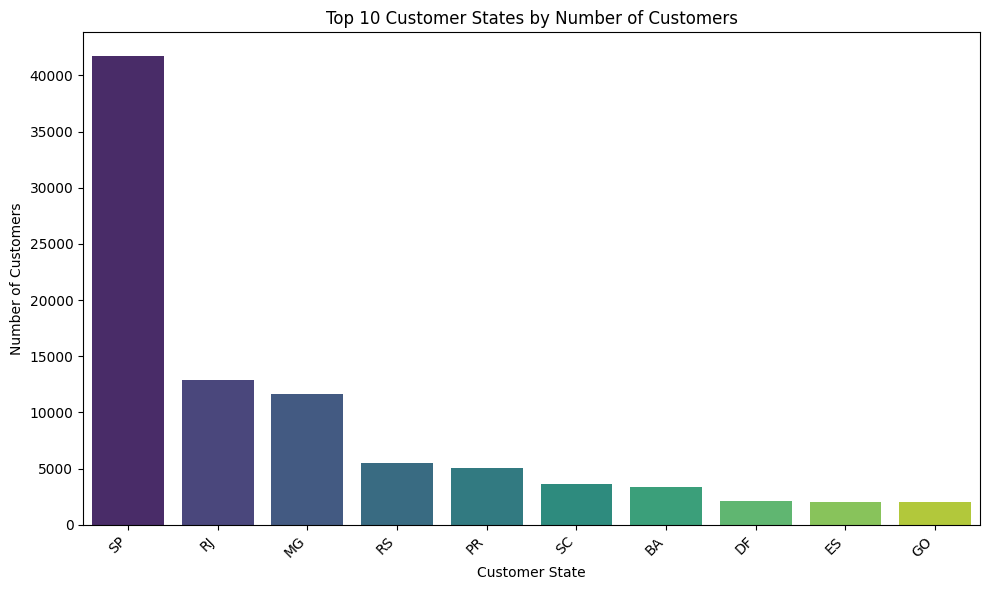

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='customer_state', y='num_customers', data=state_top10, palette='viridis')
plt.title('Top 10 Customer States by Number of Customers')
plt.xlabel('Customer State')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---

## Question 8: Monthly order trend (line chart)

**Your task:**
1. From the cleaned `orders` DataFrame (with datetime columns from Q2), extract a `year_month` period from `order_purchase_timestamp` using `.dt.to_period('M')`
2. Count orders per month — save to a DataFrame called `monthly_orders` with columns `year_month` and `num_orders`
3. Plot a **line chart** of `num_orders` over time. Add a title.

**Hint:** `orders['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()` is a fast way to get monthly counts. Convert the period index back to string for plotting.

*Skills: Sprint 4 Ch 02 (datetime), Ch 03 (groupby), Ch 04 (line chart)*

In [12]:
# 1. Extract year_month period
monthly_orders = orders['order_purchase_timestamp'].dt.to_period('M').value_counts().sort_index()

# 2. Convert to DataFrame and rename columns
monthly_orders = monthly_orders.reset_index()
monthly_orders.columns = ['year_month', 'num_orders']

# Convert year_month back to string for plotting if desired, or leave as Period for better sorting
# For plotting, often converting to string or a specific datetime format is clearer for x-axis labels
monthly_orders['year_month_str'] = monthly_orders['year_month'].astype(str)

print(monthly_orders.head())

  year_month  num_orders year_month_str
0    2016-09           4        2016-09
1    2016-10         324        2016-10
2    2016-12           1        2016-12
3    2017-01         800        2017-01
4    2017-02        1780        2017-02


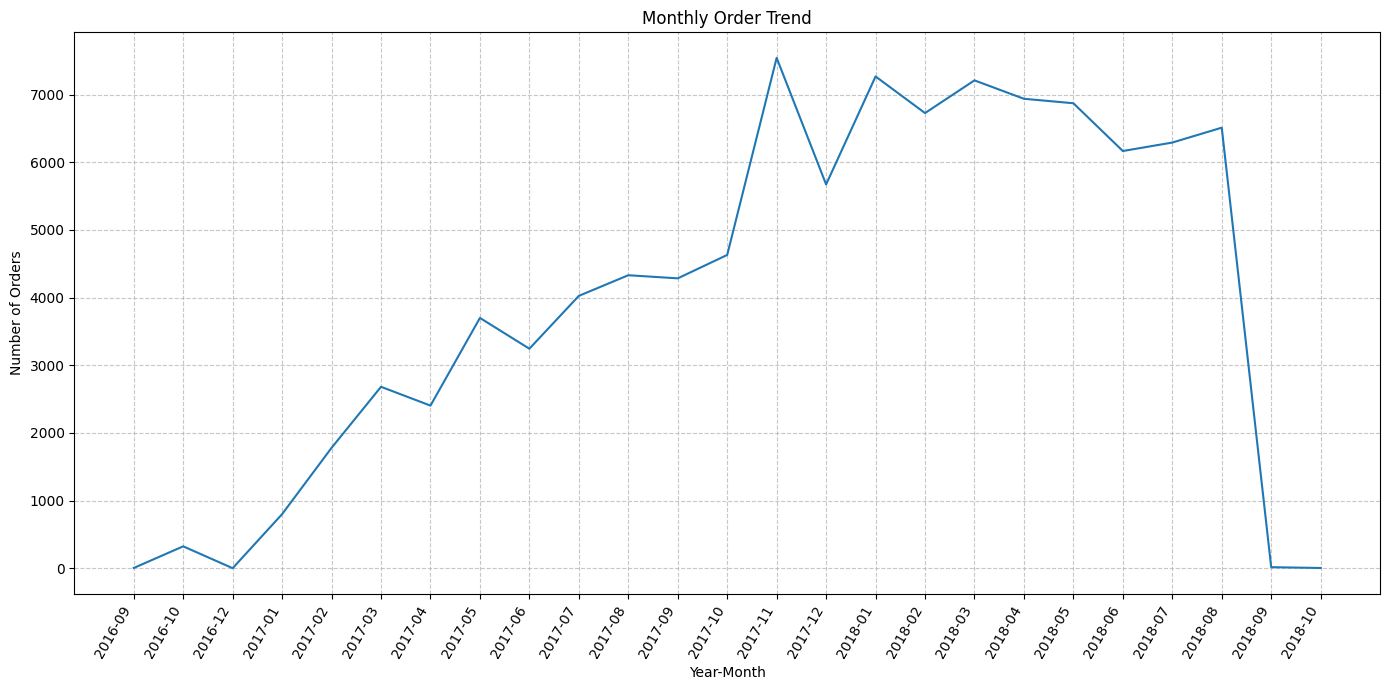

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x='year_month_str', y='num_orders', data=monthly_orders)
plt.title('Monthly Order Trend')
plt.xlabel('Year-Month')
plt.ylabel('Number of Orders')
plt.xticks(rotation=60, ha='right') # Rotate for readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

---

## Question 9: Does delivery speed affect review scores?

This is a real business question: do customers who get their orders faster leave better reviews?

**Your task:**
1. From `orders`, keep only rows where `order_delivered_customer_date` is not null
2. Add a `delivery_days` column = (delivery date − purchase date) in days. **Hint:** subtract the two datetime columns and use `.dt.days`
3. Merge with `reviews` on `order_id` to get the `review_score` for each order
4. Compute the **correlation** between `delivery_days` and `review_score` using `.corr()`
5. Group by `review_score` and show the **average delivery days** for each score (1 through 5)
6. Plot a bar chart of average delivery days by review score

What pattern do you see? Add a markdown cell with your interpretation.

*Skills: Sprint 4 Ch 03 (correlation), Ch 04 (visualization), Ch 06 (merge + groupby)*

In [14]:
# 1. Keep rows where order_delivered_customer_date is not null
delivery_data = orders.dropna(subset=['order_delivered_customer_date']).copy()

# 2. Add delivery_days column
delivery_data['delivery_days'] = (delivery_data['order_delivered_customer_date'] - delivery_data['order_purchase_timestamp']).dt.days

# 3. Merge with reviews on order_id
delivery_review = delivery_data.merge(
    reviews[['order_id', 'review_score']],
    on='order_id',
    how='inner'
)

# 4. Compute the correlation
correlation = delivery_review['delivery_days'].corr(delivery_review['review_score'])
print(f"Correlation between delivery_days and review_score: {correlation:.2f}")

# 5. Group by review_score and show average delivery days
avg_delivery_by_review = delivery_review.groupby('review_score')['delivery_days'].mean().reset_index()
avg_delivery_by_review.columns = ['review_score', 'average_delivery_days']

print("\nAverage delivery days by review score:")
print(avg_delivery_by_review)

Correlation between delivery_days and review_score: -0.33

Average delivery days by review score:
   review_score  average_delivery_days
0             1              20.849825
1             2              16.194832
2             3              13.795278
3             4              11.848054
4             5              10.224097


/tmp/ipykernel_6403/3076157697.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='review_score', y='average_delivery_days', data=avg_delivery_by_review, palette='coolwarm')


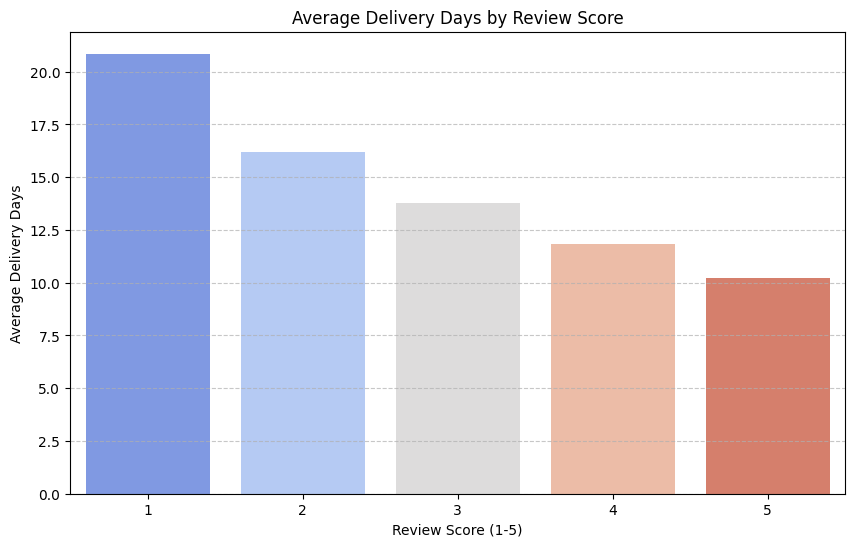

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='review_score', y='average_delivery_days', data=avg_delivery_by_review, palette='coolwarm')
plt.title('Average Delivery Days by Review Score')
plt.xlabel('Review Score (1-5)')
plt.ylabel('Average Delivery Days')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Your interpretation:**

The analysis reveals that as the delivery time increases, customer review scores tend to decrease.

The bar chart further reinforces this pattern: customers who gave 1-star reviews experienced the longest average delivery time, while those who left 5-star reviews had the shortest average delivery time. This suggests delivery significantly contributes to higher customer satisfaction.

---

## Question 10: Final Report

Write a **2–3 paragraph executive summary** of your findings as a markdown cell below. A good report answers:

- **What is the overall health of the business?** (Use Q3, Q8 — order volumes and trends)
- **Which product categories should we double down on?** (Use Q6 — revenue + review scores together)
- **Where are our customers and how do we serve them?** (Use Q7, Q9 — geography and delivery speed)
- **What is one specific recommendation you would make to the leadership team?**

Write as if you're presenting to a non-technical executive. Use plain language. Reference specific numbers from your analysis.

*Skills: Sprint 4 Ch 06 (analytical reporting)*

## Executive Summary

Overall, the E-commerce business demonstrates strong operational efficiency, with a remarkable 97% of all orders successfully delivered. Our order volume showed healthy growth throughout 2017, peaking in November 2017 with 7,288 orders. However, we've observed a noticeable decline in order volumes towards the end of 2018, which warrants further investigation to determine if this is a seasonal effect or a market shift.

From a product perspective, 'Health & Beauty' and 'Watches & Gifts' are our highest revenue-generating categories, bringing in approximately $1.45 million and $1.31 million respectively, both maintaining strong average review scores above 4.0. These are clearly areas where we should continue to invest. Our customer base is heavily concentrated, with São Paulo (SP) accounting for over 41,000 customers, followed by Rio de Janeiro (RJ) with nearly 13,000 customers. This geographic concentration highlights the importance of localized operational excellence. Critically, delivery speed is a significant driver of customer satisfaction; our analysis shows a clear trend where faster deliveries lead to higher review scores. For instance, 5-star reviews are associated with an average delivery time of 10.2 days, while 1-star reviews correlate with much longer average delivery times of 20.8 days.

**Recommendation:** To sustain growth and enhance customer loyalty, I recommend prioritizing investments in optimizing our delivery logistics, particularly in high-density customer regions like São Paulo. Expediting delivery times will directly translate to improved customer satisfaction and higher review scores, which are vital for customer retention and attracting new business. Additionally, further analysis is needed to understand the cause of the late 2018 order volume decline to inform strategic responses.